In [31]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

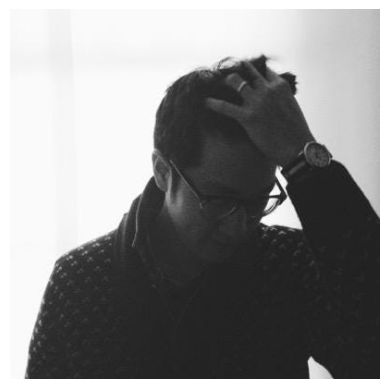

In [32]:
img = cv2.imread('anh_test.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()


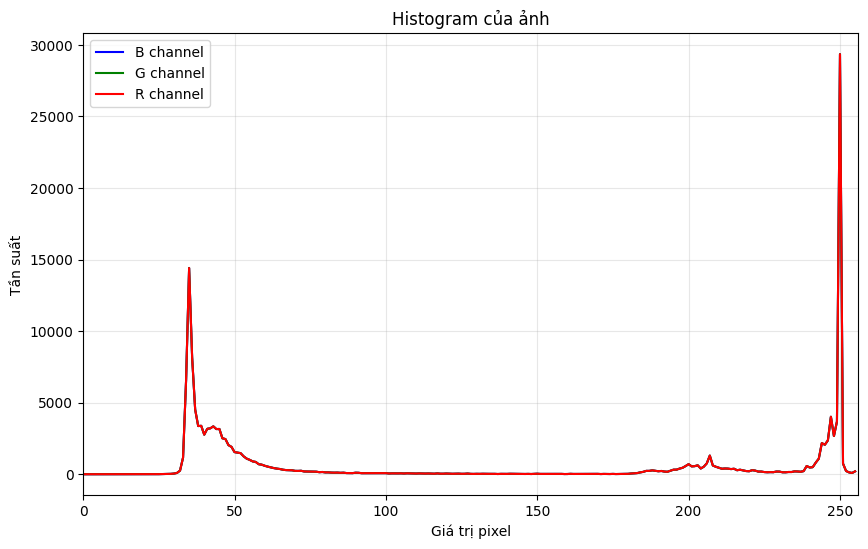

In [33]:
colors = ('b', 'g', 'r')
plt.figure(figsize=(10, 6))
for i, color in enumerate(colors):
    histogram = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histogram, color=color, label=f'{color.upper()} channel')
plt.title('Histogram của ảnh')
plt.xlabel('Giá trị pixel')
plt.ylabel('Tần suất')
plt.legend()
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)
plt.show()

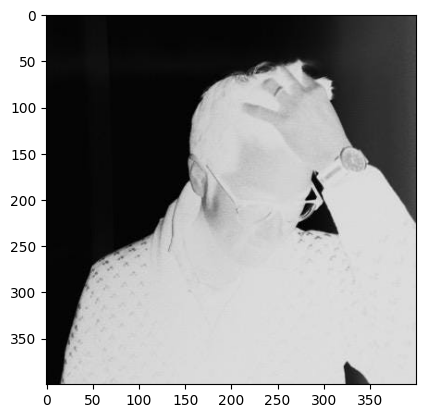

In [34]:
img_inverted = 255-img
plt.imshow(img_inverted)
plt.show()

Min value: 20
Max value: 255


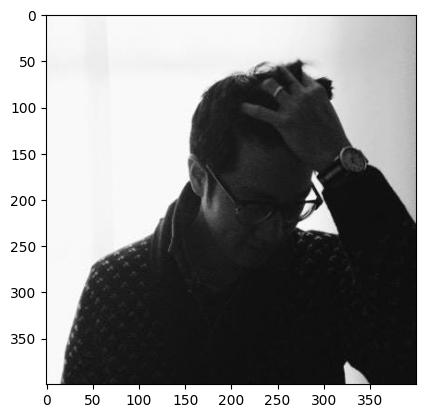

In [35]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
min_val = np.min(gray)
max_val = np.max(gray)
print("Min value:", min_val)
print("Max value:", max_val)

stretch = ((gray-min_val)/(max_val - min_val)*255).astype(np.uint8)

plt.imshow(stretch, cmap='gray')
plt.show()

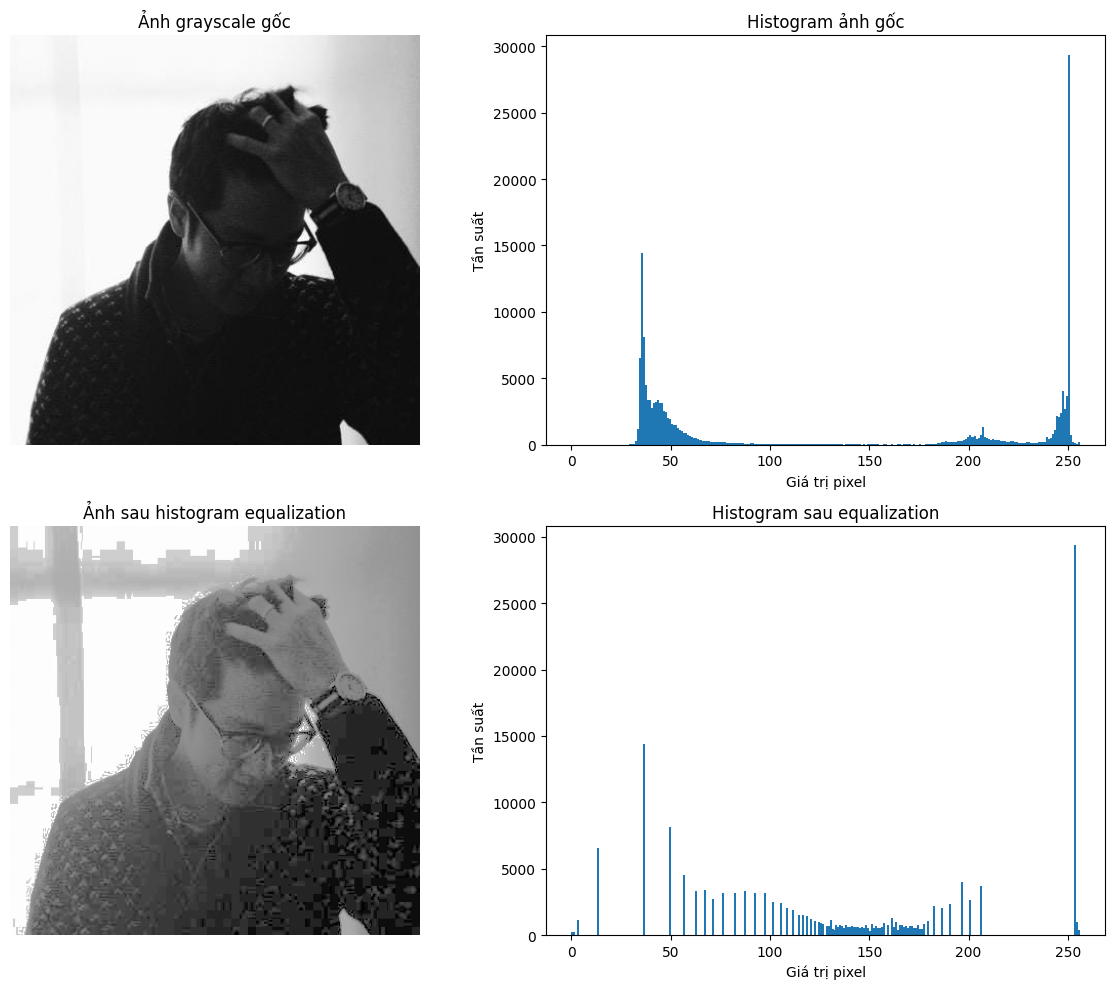

In [36]:
# Chuyển ảnh sang grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Histogram equalization để cải thiện phân phối
equalized_img = cv2.equalizeHist(gray_img)

# Hiển thị ảnh gốc và ảnh đã xử lý
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Ảnh grayscale gốc
axes[0, 0].imshow(gray_img, cmap='gray')
axes[0, 0].set_title('Ảnh grayscale gốc')
axes[0, 0].axis('off')

# Histogram của ảnh gốc
axes[0, 1].hist(gray_img.ravel(), bins=256, range=[0, 256])
axes[0, 1].set_title('Histogram ảnh gốc')
axes[0, 1].set_xlabel('Giá trị pixel')
axes[0, 1].set_ylabel('Tần suất')

# Ảnh đã equalize
axes[1, 0].imshow(equalized_img, cmap='gray')
axes[1, 0].set_title('Ảnh sau histogram equalization')
axes[1, 0].axis('off')

# Histogram của ảnh đã equalize  
axes[1, 1].hist(equalized_img.ravel(), bins=256, range=[0, 256])
axes[1, 1].set_title('Histogram sau equalization')
axes[1, 1].set_xlabel('Giá trị pixel')
axes[1, 1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

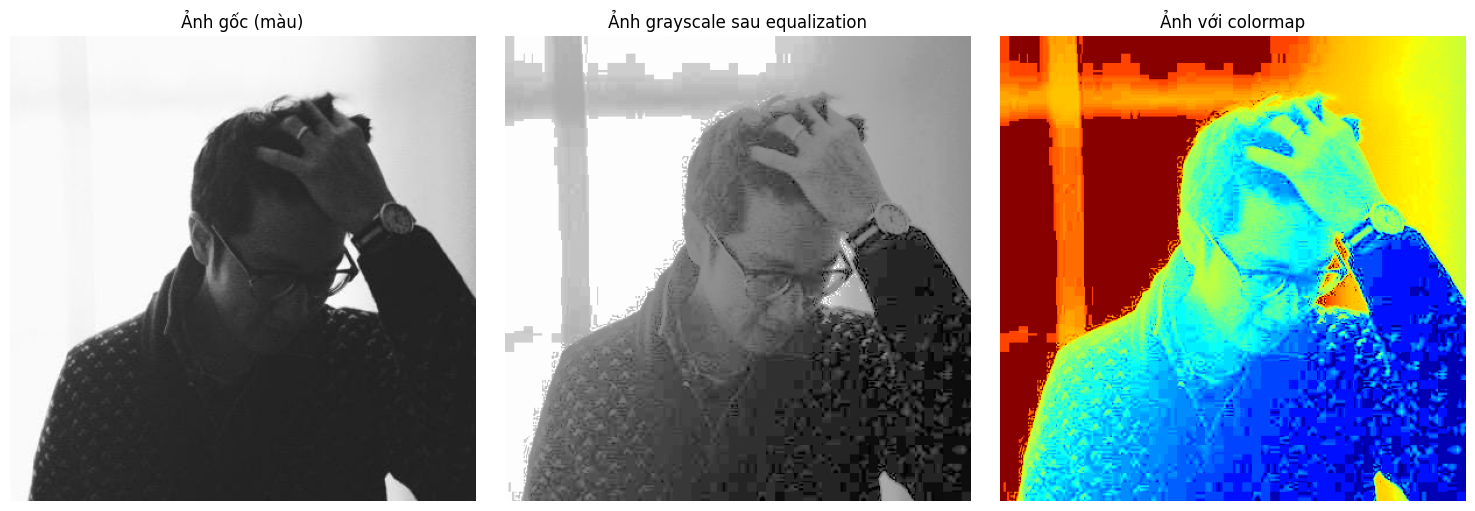

In [37]:
gray_to_bgr = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
equalized_to_bgr = cv2.cvtColor(equalized_img, cv2.COLOR_GRAY2BGR)
colormap_img = cv2.applyColorMap(equalized_img, cv2.COLORMAP_JET)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Ảnh gốc (màu)')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(equalized_img, cmap='gray')
plt.title('Ảnh grayscale sau equalization')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(colormap_img, cv2.COLOR_BGR2RGB))
plt.title('Ảnh với colormap')
plt.axis('off')
plt.tight_layout()
plt.show()

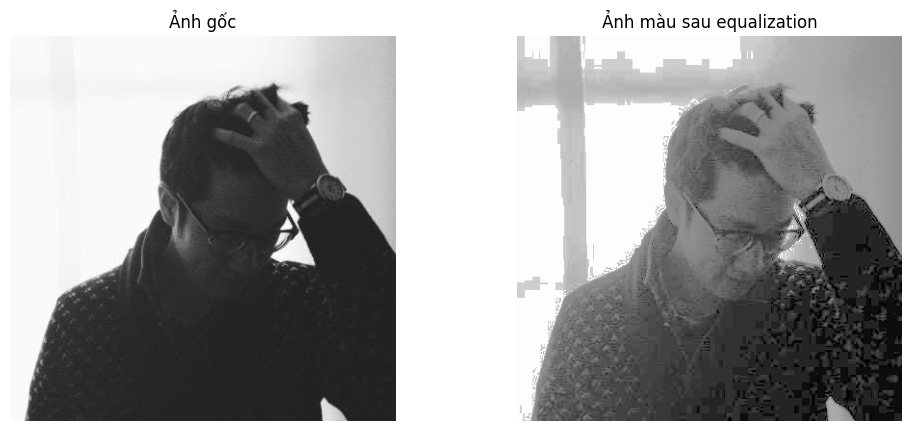

In [38]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv[:,:,2] = cv2.equalizeHist(hsv[:,:,2])
equalized_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Ảnh gốc')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(equalized_color, cv2.COLOR_BGR2RGB))
plt.title('Ảnh màu sau equalization')
plt.axis('off')
plt.show()